# Vehicle Solid Model
### Electric V-BAT-Like Tail-Sitter (EDF) — Conceptual Design Study

---

## Purpose

Generate the **parametric solid model** of the complete vehicle with
**CadQuery** (Python API over **OpenCASCADE / OCCT**), driven entirely by the
upstream design handoffs — *no geometry is hard-coded here*:

| Part | Driven by |
|------|-----------|
| Vane servos (4x) | `out/control_vanes.yaml` |
| Fuselage (body of revolution) | `out/fuselage.yaml` — same meridian function as the sizing |
| Wing (NACA section, constant chord) | mass closure + `out/airfoil.yaml` |
| Ailerons (2x, outboard TE) | `out/aileron.yaml` — split from the wing at zero deflection |
| Aileron servos (2x) | `out/aileron.yaml` — lower-surface pods, thin wing can't bury them |
| Soft-mounted FC/IMU tray + payload module | `out/vibration.yaml` + `out/fuselage.yaml` bay stations — isolated on standoffs, **assembly-only** |
| EDF duct + support struts | `out/fuselage.yaml` |
| Exhaust centerbody | `out/fuselage.yaml` + `out/control_vanes.yaml` |
| 4 × jet control vanes | `out/control_vanes.yaml` |
| 4 × landing skids on the duct | derived clearance over the vanes |

---

## Axis Convention  (Aetherion-compatible)

Body frame **FRD**: $x$ forward (out the nose), $y$ right, $z$ down.
Origin at the **nose tip**; the vehicle occupies $x \in [-L, 0]$ and the EDF
exhaust points in $-x$.  Vane labels follow NB3's aft view:
**T** $=+z$, **B** $=-z$, **L** $=+y$, **R** $=-y$.

Geometry is built in **millimetres** (STEP/STL convention); the YAML handoffs
are in metres and are scaled inside the CAD modules.

---

## Outputs

- `out/cad/step/vbat_assembly.step` — assembly with named, coloured parts
- `out/cad/step/vbat_fused.step` — single boolean-united external solid
- `out/cad/stl/vbat_fused.stl` — mesh for visualisation / 3D printing
- `out/vehicle_iso.png` — rendered preview

The fused external-aero solid deliberately **excludes** the internal
soft-mounted modules and the prop rotor; those are assembly-only (exploded
view, `step2print`), so the fused STL stays a clean external OML for CFD.

---

In [1]:
import sys, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml

REPO_ROOT   = Path().resolve().parents[0]
SRC_PATH    = REPO_ROOT / "src"
CONFIG_PATH = REPO_ROOT / "config"
OUT_PATH    = REPO_ROOT / "out"
sys.path.insert(0, str(SRC_PATH))

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.25,
    "font.size"         : 10,
})
C = ["#2c7bb6", "#d7191c", "#1a9641", "#f68b33", "#762a83"]

import cadquery as cq
print("cadquery", cq.__version__, "on OCCT (OpenCASCADE)")

FIG_DIR = Path("figures")   # per-notebook figures directory
FIG_DIR.mkdir(exist_ok=True)


cadquery 2.8.0 on OCCT (OpenCASCADE)


# Section 1 — Design Inputs

Re-run the sizing loop from `config/` (for the wing span and chord) — same
pattern as NB2/NB3/NB4 — and load the geometry handoffs written by the
previous notebooks.

---

In [2]:
from conceptual_design import (
    run_sizing_loop,
    Environment, Mission, Aerodynamics, Battery,
    WeightFraction, PropulsiveSystemParameters,
)
from conceptual_design.forward_flight_power import ForwardFlightParams
from conceptual_design.wing_sizing import WingStructureParams
from conceptual_design.models import RotorParams, Avionics

env     = Environment()
mission = Mission.from_yaml(CONFIG_PATH / "mission.yaml")
aero    = Aerodynamics.from_yaml(CONFIG_PATH / "aerodynamics.yaml")
batt    = Battery.from_yaml(CONFIG_PATH / "battery.yaml")
wf      = WeightFraction.from_yaml(CONFIG_PATH / "initial_weight_fraction_estimation.yaml")
prop    = PropulsiveSystemParameters.from_yaml(CONFIG_PATH / "propulsive_system_parameters.yaml")
ff      = ForwardFlightParams.from_yaml(CONFIG_PATH / "forward_flight_params.yaml")
ws      = WingStructureParams.from_yaml(CONFIG_PATH / "wing_structure_params.yaml")
rotor    = RotorParams.from_yaml(CONFIG_PATH / "rotor.yaml")
avionics = Avionics.from_yaml(CONFIG_PATH / "avionics.yaml")

result = run_sizing_loop(
    m_payload_kg = mission.payload_kg,
    mission      = mission,
    aero         = aero,
    batt         = batt,
    wf           = wf,
    prop_params  = prop,
    ff_params    = ff,
    ws_params    = ws,
    env          = env,
    D_rotor_m    = rotor.D_rotor_m,
    P_hotel_W    = avionics.P_hotel_W,
)

with open(OUT_PATH / "fuselage.yaml", "r") as f:
    fus = yaml.safe_load(f)
with open(OUT_PATH / "control_vanes.yaml", "r") as f:
    vanes = yaml.safe_load(f)
with open(OUT_PATH / "aileron.yaml", "r") as f:
    ail = yaml.safe_load(f)
with open(OUT_PATH / "airfoil.yaml", "r") as f:
    af = yaml.safe_load(f)

b_wing_m     = result.wing.b_wing
chord_wing_m = result.wing.chord_mean

print(f"Fuselage       : D = {fus['D_fus_m']*1e3:.1f} mm, L = {fus['L_fus_m']*1e3:.1f} mm "
      f"({fus['active_constraint']}-constrained)")
print(f"Wing           : {af['designation']},  b = {b_wing_m*1e3:.0f} mm,  c = {chord_wing_m*1e3:.1f} mm, "
      f"LE at station {fus['x_wing_LE_m']*1e3:.1f} mm")
print(f"Ailerons       : 2 x, c = {ail['c_aileron_m']*1e3:.1f} mm, b = {ail['b_aileron_m']*1e3:.1f} mm "
      f"(span_frac={ail['span_frac_wing']:.2f}, chord_frac={ail['chord_frac']:.2f})")
print(f"Duct           : {fus['D_duct_inner_m']*1e3:.0f} / {fus['D_duct_outer_m']*1e3:.0f} mm, "
      f"chord {fus['duct_chord_m']*1e3:.0f} mm")
print(f"Vanes          : {vanes['n_vanes']} x flat plate, c = {vanes['c_vane_m']*1e3:.1f} mm, "
      f"h = {vanes['h_vane_m']*1e3:.1f} mm, at station {fus['x_vane_m']*1e3:.1f} mm")
print(f"Axis convention: {fus['axis_convention']}")

Fuselage       : D = 97.7 mm, L = 488.3 mm (packaging-constrained)
Wing           : NACA 2412,  b = 1093 mm,  c = 182.2 mm, LE at station 204.7 mm
Ailerons       : 2 x, c = 21.9 mm, b = 65.6 mm (span_frac=0.12, chord_frac=0.12)
Duct           : 201 / 217 mm, chord 88 mm
Vanes          : 4 x flat plate, c = 19.9 mm, h = 49.7 mm, at station 513.2 mm
Axis convention: body FRD (x fwd, y right, z down); stations from nose, +aft; x_body = -station


# Section 2 — Build the Solid Model

`conceptual_design.cad.vehicle_assembly.build_vehicle()` constructs every part
with OCCT booleans:

- the fuselage **revolves the exact meridian function** used by the sizing
  notebook (`fuselage_design.fuselage_radius`) — one source of truth,
- the wing extrudes the cambered NACA section from the NB2 airfoil math,
- vane roots are embedded 4 mm into the exhaust centerbody so the fused
  model is a **single watertight solid**.

---

In [3]:
from conceptual_design.cad.vehicle_assembly import (
    build_vehicle, export_vehicle, isolated_fc_tray, soft_mounted_nose,
)
from conceptual_design.cad.prop_rotor import (
    PropGeometry, build_prop_rotor, export_prop_rotor,
)
from conceptual_design.cad.fuselage_body import MM

asm, fused = build_vehicle(
    fus              = fus,
    vanes            = vanes,
    ail              = ail,
    b_wing_m         = b_wing_m,
    chord_wing_m     = chord_wing_m,
    wing_designation = af["designation"],
)

# -- parametric EDF fan rotor (config/prop_geometry.yaml) ----------------
# Added to the ASSEMBLY for visualisation and exported standalone for
# rotating-zone CFD.  Deliberately NOT fused into the external-aero STL:
# the vehicle CFD models the fan as an actuator disk.
pg    = PropGeometry.from_yaml(CONFIG_PATH / "prop_geometry.yaml")
rotor_solid = build_prop_rotor(rotor.D_rotor_m, pg)

x_fan_c = next(it["x_cg_m"] for it in fus["layout"] if it["name"] == "duct")
rotor_placed = rotor_solid.translate((-(x_fan_c * MM), 0, 0))
asm.add(rotor_placed, name="prop_rotor", color=cq.Color(0.95, 0.60, 0.10))

# -- soft-mounted internal modules (NB5 vibration isolation) -------------
# The FC/IMU tray and the payload nose module hang off the shell on
# isolators with a rattle gap.  INTERNAL parts: added to the assembly /
# exploded view only, NOT fused into the external-aero STL.
layout   = {it["name"]: it for it in fus["layout"]}
r_int_m  = fus["D_fus_m"] / 2.0 - 0.0008          # internal shell radius
iso_col  = cq.Color(0.55, 0.20, 0.75)             # purple: isolated modules
fc_tray  = isolated_fc_tray(layout["avionics"]["x_cg_m"], r_int_m)
nose_mod = soft_mounted_nose(layout["payload"]["x_cg_m"],
                             layout["payload"]["length_m"], r_int_m)
asm.add(fc_tray,  name="fc_imu_tray",   color=iso_col)
asm.add(nose_mod, name="payload_module", color=iso_col)

solids = fused.solids().vals()
bb = fused.val().BoundingBox()
rbb = rotor_solid.val().BoundingBox()
print(f"Assembly parts   : {len(asm.children)}  (incl. prop_rotor {pg.n_blades} blades, "
      f"2 ailerons, 2 soft-mounted modules)")
print(f"Fused solids     : {len(solids)}  (1 = watertight; rotor + internal modules kept separate)")
print(f"Rotor            : D = {rbb.zmax-rbb.zmin:.1f} mm, "
      f"{len(rotor_solid.solids().vals())} solid(s)")
print(f"Bounding box     : x [{bb.xmin:7.1f}, {bb.xmax:7.1f}] mm  (length {bb.xmax-bb.xmin:.1f})")
print(f"                   y [{bb.ymin:7.1f}, {bb.ymax:7.1f}] mm  (span   {bb.ymax-bb.ymin:.1f})")
print(f"                   z [{bb.zmin:7.1f}, {bb.zmax:7.1f}] mm  (height {bb.zmax-bb.zmin:.1f})")
print(f"Enclosed volume  : {fused.val().Volume()/1e6:.2f} L (solid, not shelled)")

Assembly parts   : 27  (incl. prop_rotor 11 blades, 2 ailerons, 2 soft-mounted modules)
Fused solids     : 1  (1 = watertight; rotor + internal modules kept separate)
Rotor            : D = 194.6 mm, 1 solid(s)
Bounding box     : x [ -548.2,     0.0] mm  (length 548.2)
                   y [ -546.6,   546.6] mm  (span   1093.3)
                   z [ -108.5,   108.5] mm  (height 217.0)
Enclosed volume  : 6.63 L (solid, not shelled)


# Section 3 — STEP / STL Export

- **`vbat_assembly.step`** keeps parts separate with names and colours — for
  CAD exchange and detail design.
- **`vbat_fused.step`** and **`vbat_fused.stl`** are the united solid — for
  quick visualisation, CFD meshing, or 3D printing a display model.

---

In [4]:
paths = export_vehicle(asm, fused, OUT_PATH / "cad")
for k, v in paths.items():
    if k == "parts":
        continue
    size_kb = Path(v).stat().st_size / 1024
    print(f"{k:<14}: {v}   ({size_kb:,.0f} kB)")
print(f"parts         : {len(paths['parts'])} x STEP+STL under cad/step/parts, cad/stl/parts")

# standalone rotor exports (local rotor frame: axis +x, disk at x = 0)
rotor_paths = export_prop_rotor(rotor_solid, OUT_PATH / "cad")
for k, v in rotor_paths.items():
    size_kb = Path(v).stat().st_size / 1024
    print(f"prop {k:<9}: {v}   ({size_kb:,.0f} kB)")

step_assembly : D:\Dev\vbat-uav-notebooks\out\cad\step\vbat_assembly.step   (12,436 kB)
step_fused    : D:\Dev\vbat-uav-notebooks\out\cad\step\vbat_fused.step   (3,216 kB)
stl           : D:\Dev\vbat-uav-notebooks\out\cad\stl\vbat_fused.stl   (1,068 kB)
parts         : 27 x STEP+STL under cad/step/parts, cad/stl/parts


prop step     : D:\Dev\vbat-uav-notebooks\out\cad\step\prop_rotor.step   (10,179 kB)
prop stl      : D:\Dev\vbat-uav-notebooks\out\cad\stl\prop_rotor.stl   (1,239 kB)


# Section 4 — Rendered Preview

Tessellate the fused solid (OCCT mesher) and render with matplotlib.
Plotted axes are $(x_{body},\, y_{body},\, -z_{body})$ so **up in the figure
is up in cruise flight** (FRD $z$ points down).

---

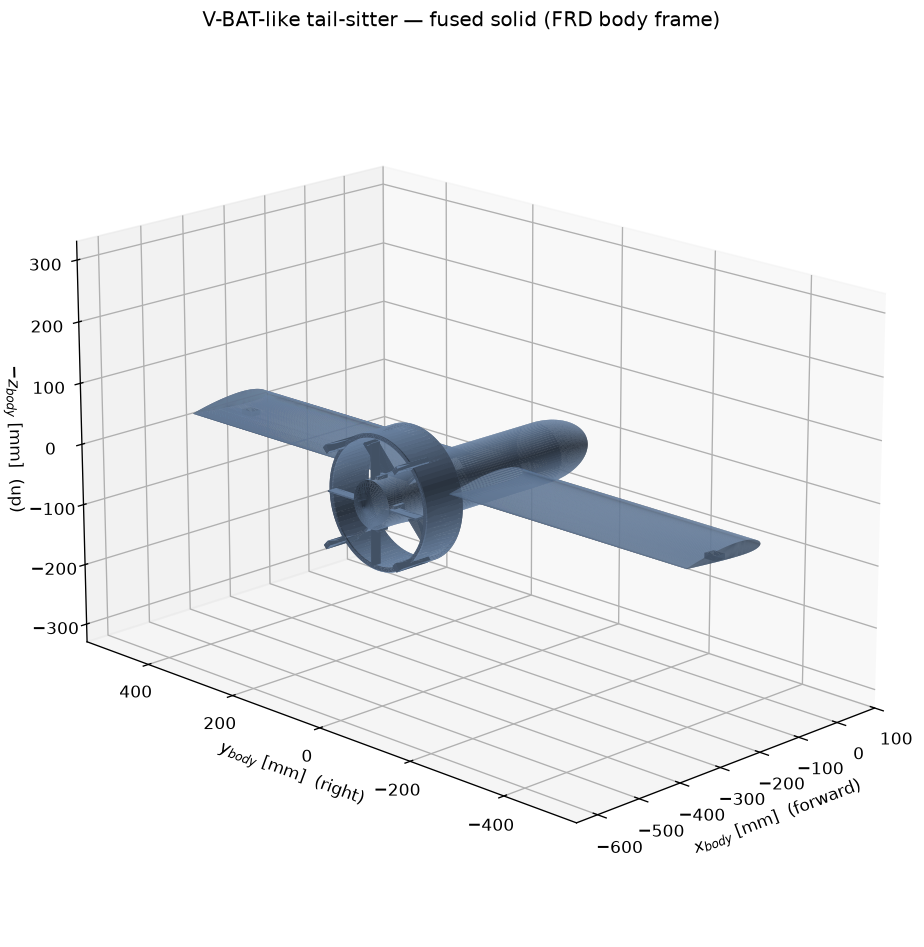

21,867 triangles rendered


In [5]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.colors import LightSource

verts, faces = fused.val().tessellate(1.5)
V = np.array([(v.x, v.y, -v.z) for v in verts])   # -z: plot up = flight up
F = np.array(faces)

tri = V[F]
# simple directional shading
n = np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0])
n /= (np.linalg.norm(n, axis=1, keepdims=True) + 1e-12)
light = np.array([0.4, 0.35, 0.85]); light = light / np.linalg.norm(light)
shade = 0.35 + 0.65 * np.clip(np.abs(n @ light), 0, 1)
base = np.array([0.45, 0.55, 0.68])
colors = np.clip(shade[:, None] * base[None, :], 0, 1)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
pc = Poly3DCollection(tri, facecolors=colors, edgecolor="none")
ax.add_collection3d(pc)

lim = 550
ax.set_xlim(-2*lim/2 - 100, 100)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim*0.6, lim*0.6)
ax.set_box_aspect((1.1, 1.8, 1.1))
ax.view_init(elev=18, azim=-135)
ax.set_xlabel("$x_{body}$ [mm]  (forward)")
ax.set_ylabel("$y_{body}$ [mm]  (right)")
ax.set_zlabel("$-z_{body}$ [mm]  (up)")
ax.set_title("V-BAT-like tail-sitter — fused solid (FRD body frame)")
fig.tight_layout()
fig.savefig(OUT_PATH / "vehicle_iso.png", bbox_inches="tight", dpi=130)
plt.show()
print(f"{len(F):,} triangles rendered")

# Section 5 — Model Summary

In [6]:
bar = "=" * 60
print(bar)
print("  VEHICLE SOLID MODEL SUMMARY".center(60))
print(bar)
print(f"  {'Overall length (incl. legs)':<34}: {bb.xmax-bb.xmin:8.1f} mm")
print(f"  {'Wing span':<34}: {bb.ymax-bb.ymin:8.1f} mm")
print(f"  {'Duct outer diameter':<34}: {fus['D_duct_outer_m']*1e3:8.1f} mm")
print(f"  {'Fuselage D x L':<34}: {fus['D_fus_m']*1e3:.1f} x {fus['L_fus_m']*1e3:.1f} mm")
print(f"  {'Wing section':<34}: {af['designation']:>8s}")
print()
print("  Parts in STEP assembly:")
for child in asm.children:
    print(f"    - {child.name}")
print()
print(f"  {'Watertight fused solid':<34}: {'YES' if len(solids)==1 else 'NO -- ' + str(len(solids)) + ' bodies'}")
print(bar)
print("  Axis convention: body FRD (x fwd, y right, z down),")
print("  origin at nose tip, exhaust in -x  [Aetherion]")
print(bar)

                 VEHICLE SOLID MODEL SUMMARY                
  Overall length (incl. legs)       :    548.2 mm
  Wing span                         :   1093.3 mm
  Duct outer diameter               :    217.0 mm
  Fuselage D x L                    : 97.7 x 488.3 mm
  Wing section                      : NACA 2412

  Parts in STEP assembly:
    - fuselage
    - wing
    - aileron_L
    - aileron_R
    - duct
    - centerbody
    - strut_1
    - strut_2
    - strut_3
    - strut_4
    - vane_T
    - vane_B
    - vane_L
    - vane_R
    - servo_T
    - servo_B
    - servo_L
    - servo_R
    - servo_aileron_L
    - servo_aileron_R
    - leg_1
    - leg_2
    - leg_3
    - leg_4
    - prop_rotor
    - fc_imu_tray
    - payload_module

  Watertight fused solid            : YES
  Axis convention: body FRD (x fwd, y right, z down),
  origin at nose tip, exhaust in -x  [Aetherion]
